# Multigraph Algorithm Analysis

## Overview
This notebook analyzes the performance and accuracy of algorithms designed for the **Multigraph Subgraph Extension Problem**.

### Problem Statement
Given a pattern graph $G$ and a host graph $H$, we want to find if $G \subseteq H$. If not, we want to find a **minimal extension** $H'$ of $H$ such that $G \subseteq H'$, minimizing the number of added edges (the "cost").

### Algorithms Tested
1.  **Exact Algorithm**: Uses a Branch & Bound approach to find the optimal extension with minimum cost. It guarantees the best solution but has exponential time complexity.
2.  **Approximate Algorithm**: Uses a heuristic based on the Hungarian algorithm (linear assignment) to find a "good enough" mapping and extension. It is much faster but may not find the optimal cost.

### Experiments
We analyze three key aspects:
1.  **Accuracy**: How close is the Approximate solution to the Exact solution? (Approximation Ratio)
2.  **Scalability**: How does the runtime of the Approximate algorithm grow with graph size?
3.  **Density Impact**: How does graph density affect the heuristic's performance?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from IPython.display import Image, display

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## Load Latest Experiment Data

In [5]:
# Find latest experiment folder
exp_dirs = glob.glob("experiments/exp_*")
latest_exp = max(exp_dirs, key=os.path.getmtime)
print(f"Loading data from: {latest_exp}")

df = pd.read_csv(os.path.join(latest_exp, "results.csv"))
df.head()

Loading data from: experiments/exp_20251202_155216


,experiment,size_G,size_H,density,exact_time,approx_time,exact_cost,approx_cost,exact_found,approx_found,algorithm,time,cost
0,accuracy,3,5.0,0.5,2.190113,1.745462,0.0,0.0,True,True,NaN,NaN,NaN
1,accuracy,3,5.0,0.5,1.674414,1.628637,3.0,5.0,False,False,NaN,NaN,NaN
2,accuracy,3,5.0,0.5,1.799107,1.246214,0.0,0.0,True,True,NaN,NaN,NaN
3,accuracy,3,5.0,0.5,1.850843,2.170324,4.0,4.0,False,False,NaN,NaN,NaN
4,accuracy,3,5.0,0.5,2.136230,2.006531,0.0,0.0,True,True,NaN,NaN,NaN


## 1. Accuracy Analysis (Exact vs Approx)

We compare the **Minimal Extension Cost** (number of edges added) found by the Approximate algorithm against the optimal cost found by the Exact algorithm.

### Metric: Approximation Ratio
$$ \text{Ratio} = \frac{\text{Cost}_{\text{Approx}}}{\text{Cost}_{\text{Exact}}} $$

*   **Ratio = 1.0**: The Approximate algorithm found the optimal solution.
*   **Ratio > 1.0**: The Approximate algorithm added more edges than necessary (suboptimal).
*   **Ratio < 1.0**: Impossible (since Exact is optimal).

*Note: If Exact Cost is 0 (perfect subgraph found), we define the ratio as 1.0 if Approx also found it, or penalize it if it didn't.*

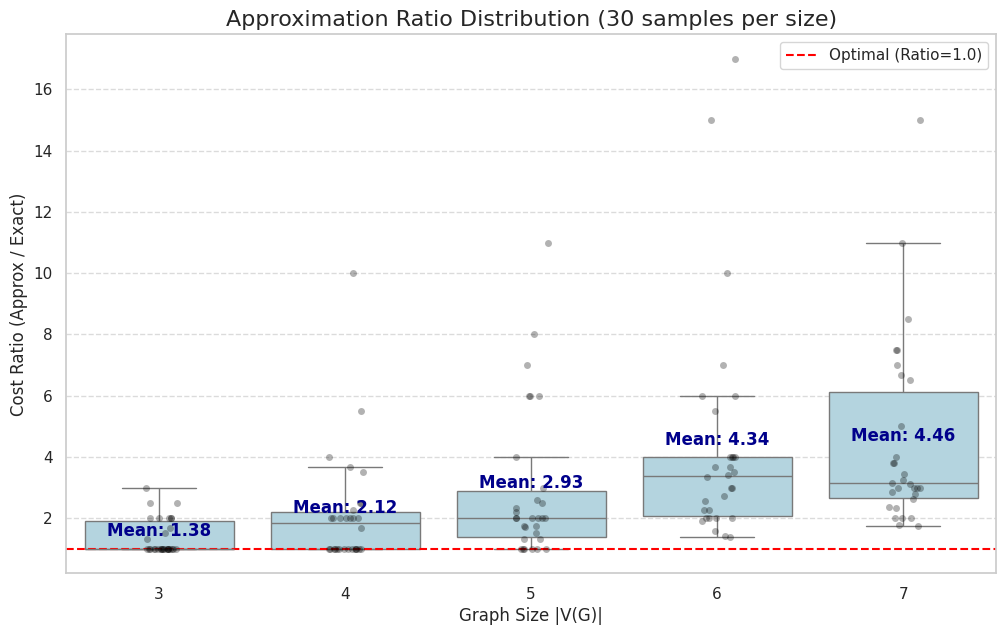

In [6]:
acc_df = df[df['experiment'] == 'accuracy'].copy()

# Calculate Ratio
acc_df['cost_ratio'] = acc_df.apply(lambda row: row['approx_cost'] / row['exact_cost'] if row['exact_cost'] > 0 else (1.0 if row['approx_cost'] == 0 else 2.0), axis=1)

plt.figure(figsize=(12, 7))

# Boxplot to show statistical distribution
sns.boxplot(data=acc_df, x='size_G', y='cost_ratio', color='lightblue', showfliers=False)
sns.stripplot(data=acc_df, x='size_G', y='cost_ratio', color='black', alpha=0.3, jitter=True)

plt.axhline(1.0, color='red', linestyle='--', label="Optimal (Ratio=1.0)")

# Calculate and display mean ratio per size
means = acc_df.groupby('size_G')['cost_ratio'].mean()
for size, mean_val in means.items():
    # Adjust x-coordinate (size starts at 3, so index is size-3)
    plt.text(size-3, mean_val + 0.05, f"Mean: {mean_val:.2f}", ha='center', color='darkblue', fontweight='bold')

plt.title("Approximation Ratio Distribution (30 samples per size)", fontsize=16)
plt.ylabel("Cost Ratio (Approx / Exact)", fontsize=12)
plt.xlabel("Graph Size |V(G)|", fontsize=12)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Scalability Analysis

We compare the runtime scaling of the **Exact** and **Approximate** algorithms.
*   **Exact**: Tested on sizes 3 to 9. We expect exponential growth.
*   **Approx**: Tested on sizes 5 to 50. We expect polynomial growth.
*   **Visualization**: Log-scale Y-axis to clearly show the divergence in complexity classes.

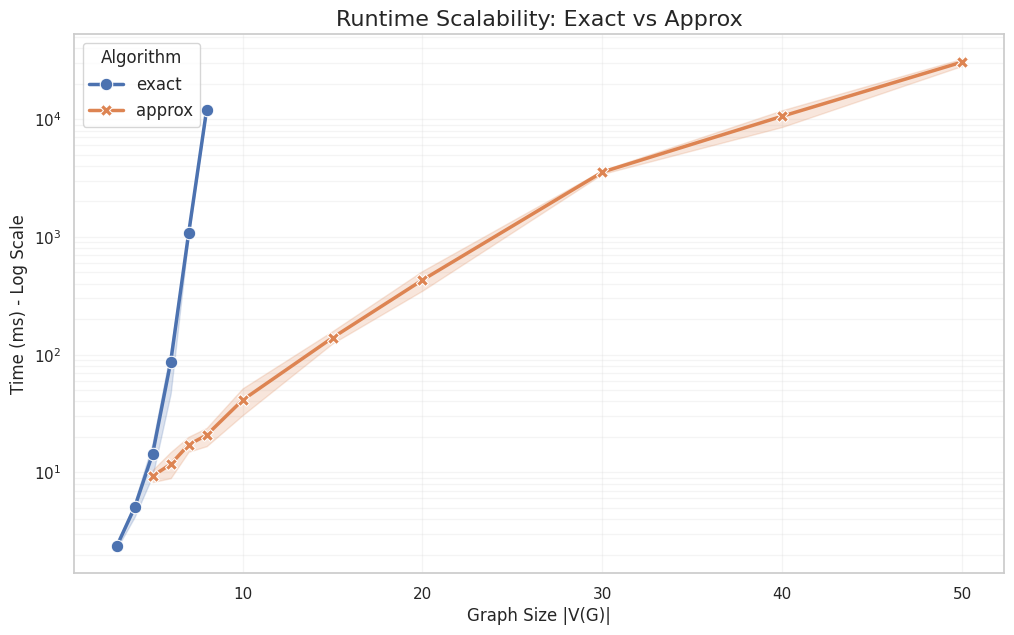

In [7]:
scale_df = df[df['experiment'] == 'scalability']

plt.figure(figsize=(12, 7))

# Plot both algorithms
sns.lineplot(data=scale_df, x='size_G', y='time', hue='algorithm', style='algorithm', markers=True, dashes=False, linewidth=2.5, markersize=9)

plt.title("Runtime Scalability: Exact vs Approx", fontsize=16)
plt.ylabel("Time (ms) - Log Scale", fontsize=12)
plt.xlabel("Graph Size |V(G)|", fontsize=12)
plt.yscale('log') 

# Annotate the crossover or divergence
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Algorithm", fontsize=12)
plt.show()

## 3. Density Impact Analysis

We investigate how the **Edge Density** of the graphs affects the runtime of both algorithms.
*   **Exact Algorithm**: Tested on small graphs ($|V(G)|=7$).
*   **Approx Algorithm**: Tested on medium ($|V(G)|=15$) and large ($|V(G)|=30$) graphs.
*   **Density Range**: $0.1$ (Sparse) to $0.9$ (Dense).

*Hypothesis*: 
*   **Exact**: Higher density might increase pruning effectiveness (faster) or increase the search space of edges (slower).
*   **Approx**: Higher density increases the complexity of the matching cost calculation but might provide more "signal" for the heuristic.

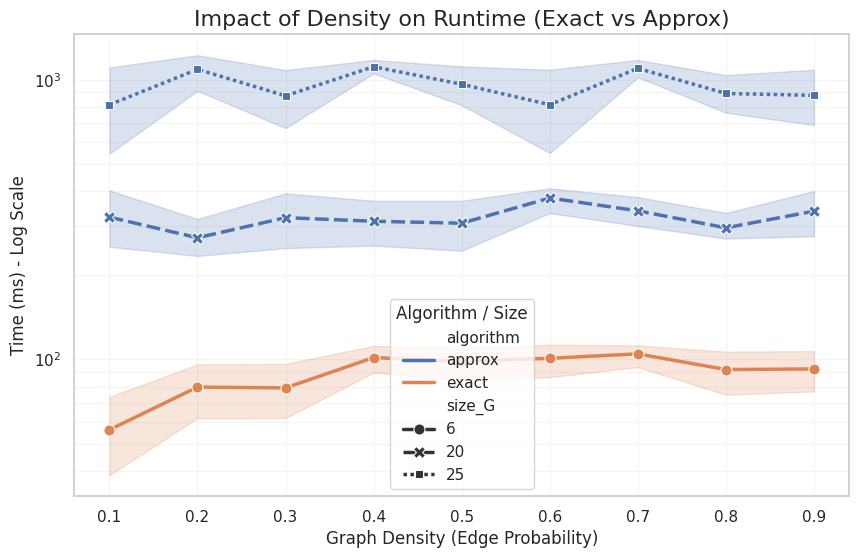

In [8]:
dens_df = df[df['experiment'] == 'density']

plt.figure(figsize=(10, 6))
# Use 'time' as y-axis, distinguish by algorithm (hue) and graph size (style)
sns.lineplot(data=dens_df, x='density', y='time', hue='algorithm', style='size_G', markers=True, linewidth=2.5, markersize=8)

plt.title("Impact of Density on Runtime (Exact vs Approx)", fontsize=16)
plt.ylabel("Time (ms) - Log Scale", fontsize=12)
plt.xlabel("Graph Density (Edge Probability)", fontsize=12)
plt.yscale('log') # Log scale is essential due to Exact's complexity
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(title="Algorithm / Size")
plt.show()

## 4. Qualitative Visualization

We visualize a specific test case ($|V(G)|=7$) to compare the solutions found by both algorithms.
*   **Pattern Graph G**: The graph we want to embed.
*   **Host Graph H**: The target graph.
*   **Exact Extension**: The optimal set of edges added to H to contain G.
*   **Approx Extension**: The set of edges added by the heuristic.

*Legend*:
*   **Black Lines**: Original edges of H.
*   **Red Dashed Lines**: New edges added by the algorithm.

Visual Comparison of Extensions (Red Dashed Lines = Added Edges)


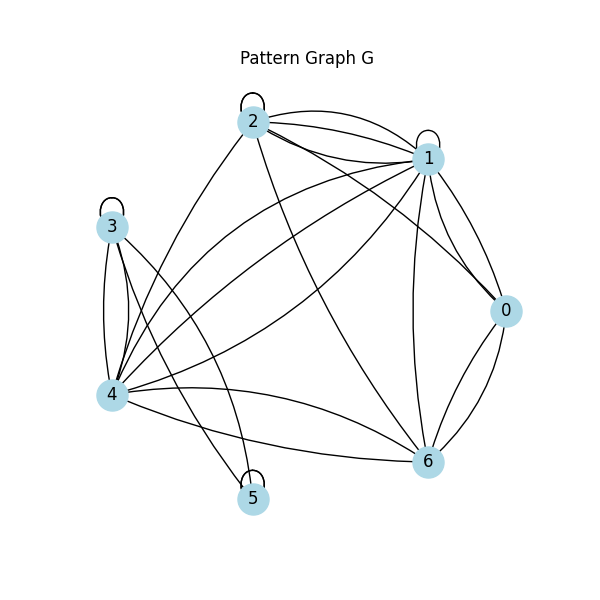

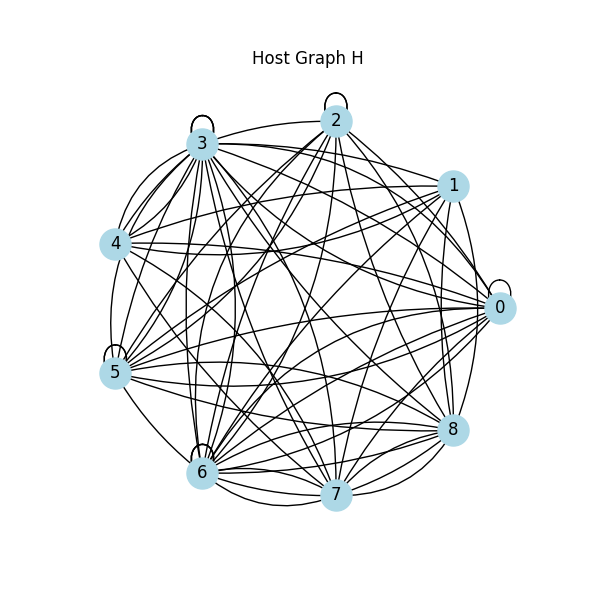

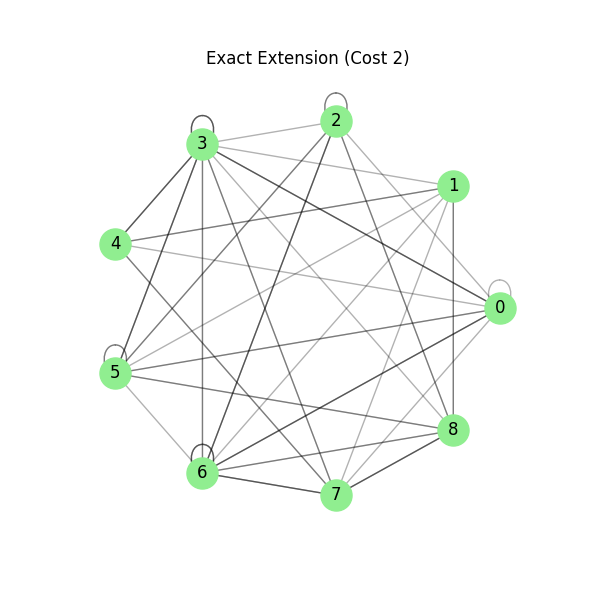

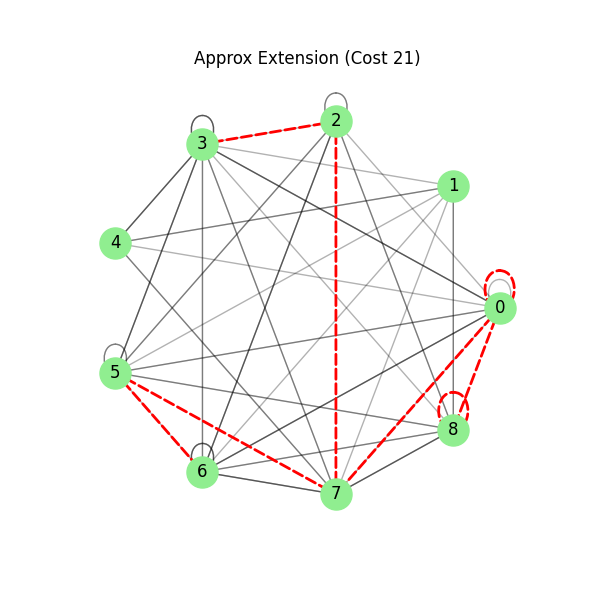

In [9]:
viz_dir = os.path.join(latest_exp, "visualizations")

# Display Comparison Images
print("Visual Comparison of Extensions (Red Dashed Lines = Added Edges)")
comp_images = ["comparison_G.png", "comparison_H.png", "comparison_Exact.png", "comparison_Approx.png"]

for img_name in comp_images:
    path = os.path.join(viz_dir, img_name)
    if os.path.exists(path):
        display(Image(filename=path))
    else:
        print(f"Image not found: {img_name}")